In [1]:
try:
    import tensorflow as tf
    print("TF version:", tf.__version__)
except:
    print("TensorFlow not installed — run: pip install tensorflow")

TensorFlow not installed — run: pip install tensorflow


In [2]:
import sys
!{sys.executable} -m pip install tensorflow

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.2/223.2 MB 6.9 MB/s  0:00:33 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 6.5 MB/s  0:00:016.6 MB/s eta 0:00:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 6.9 MB/s  0:00:00m 6.9 MB/s eta 0:0

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
np.random.seed(42)

In [3]:
df = pd.read_csv("../data/final_spatial_irrigation_dataset.csv")
df = df.sort_values("Date").reset_index(drop=True)

FEATURES    = ["Temperature", "Humidity", "Rainfall"]
TARGET      = "Water_Liters"
WINDOW_SIZE = 7

feat_scaler   = MinMaxScaler()
target_scaler = MinMaxScaler()

X_scaled = feat_scaler.fit_transform(df[FEATURES])
y_scaled = target_scaler.fit_transform(df[[TARGET]]).flatten()

print("Data loaded:", df.shape)

Data loaded: (54810, 9)


In [4]:
def make_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i : i + window])
        ys.append(y[i + window])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_scaled, y_scaled, WINDOW_SIZE)

split = int(len(X_seq) * 0.8)
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]

print(f"Train: {X_tr.shape}  |  Test: {X_te.shape}")

Train: (43842, 7, 3)  |  Test: (10961, 7, 3)


In [5]:
input_shape = (WINDOW_SIZE, len(FEATURES))
es = EarlyStopping(patience=15, restore_best_weights=True)

def build_lstm1():
    m = Sequential([
        LSTM(64, input_shape=input_shape),
        Dropout(0.2), Dense(32, activation="relu"), Dense(1)
    ])
    m.compile(optimizer=Adam(1e-3), loss="mse")
    return m

def build_lstm2():
    m = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.2), LSTM(64), Dropout(0.2),
        Dense(32, activation="relu"), Dense(1)
    ])
    m.compile(optimizer=Adam(1e-3), loss="mse")
    return m

def build_bilstm():
    m = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=input_shape),
        Dropout(0.2), Bidirectional(LSTM(32)), Dropout(0.2),
        Dense(32, activation="relu"), Dense(1)
    ])
    m.compile(optimizer=Adam(1e-3), loss="mse")
    return m

variants = {"LSTM-1Layer": build_lstm1(), "LSTM-2Layer": build_lstm2(), "Bi-LSTM": build_bilstm()}
predictions = {}
lstm_results = {}

for name, model in variants.items():
    print(f"Training {name}...")
    model.fit(X_tr, y_tr, epochs=150, batch_size=32,
              validation_split=0.15, callbacks=[es], verbose=0)
    y_pred = target_scaler.inverse_transform(model.predict(X_te)).flatten()
    y_actual = target_scaler.inverse_transform(y_te.reshape(-1,1)).flatten()
    predictions[name] = y_pred
    r2   = r2_score(y_actual, y_pred)
    mae  = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    lstm_results[name] = {"R²": r2, "MAE": mae, "RMSE": rmse}
    print(f"  ✅ {name}: R²={r2:.4f}  MAE={mae:.1f}  RMSE={rmse:.1f}")

Training LSTM-1Layer...
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step
  ✅ LSTM-1Layer: R²=0.3129  MAE=33590.3  RMSE=42598.9
Training LSTM-2Layer...
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  ✅ LSTM-2Layer: R²=0.2856  MAE=34107.2  RMSE=43434.7
Training Bi-LSTM...
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
  ✅ Bi-LSTM: R²=0.2908  MAE=33999.5  RMSE=43279.0


In [6]:
results_df = pd.DataFrame(lstm_results).T
results_df.loc["XGBoost (ref)"] = {"R²": 0.9998, "MAE": 31.0, "RMSE": 40.0}
display(results_df.round(4))

,R²,MAE,RMSE
LSTM-1Layer,0.3129,33590.2600,42598.9071
LSTM-2Layer,0.2856,34107.2232,43434.6908
Bi-LSTM,0.2908,33999.4621,43278.9959
XGBoost (ref),0.9998,31.0000,40.0000


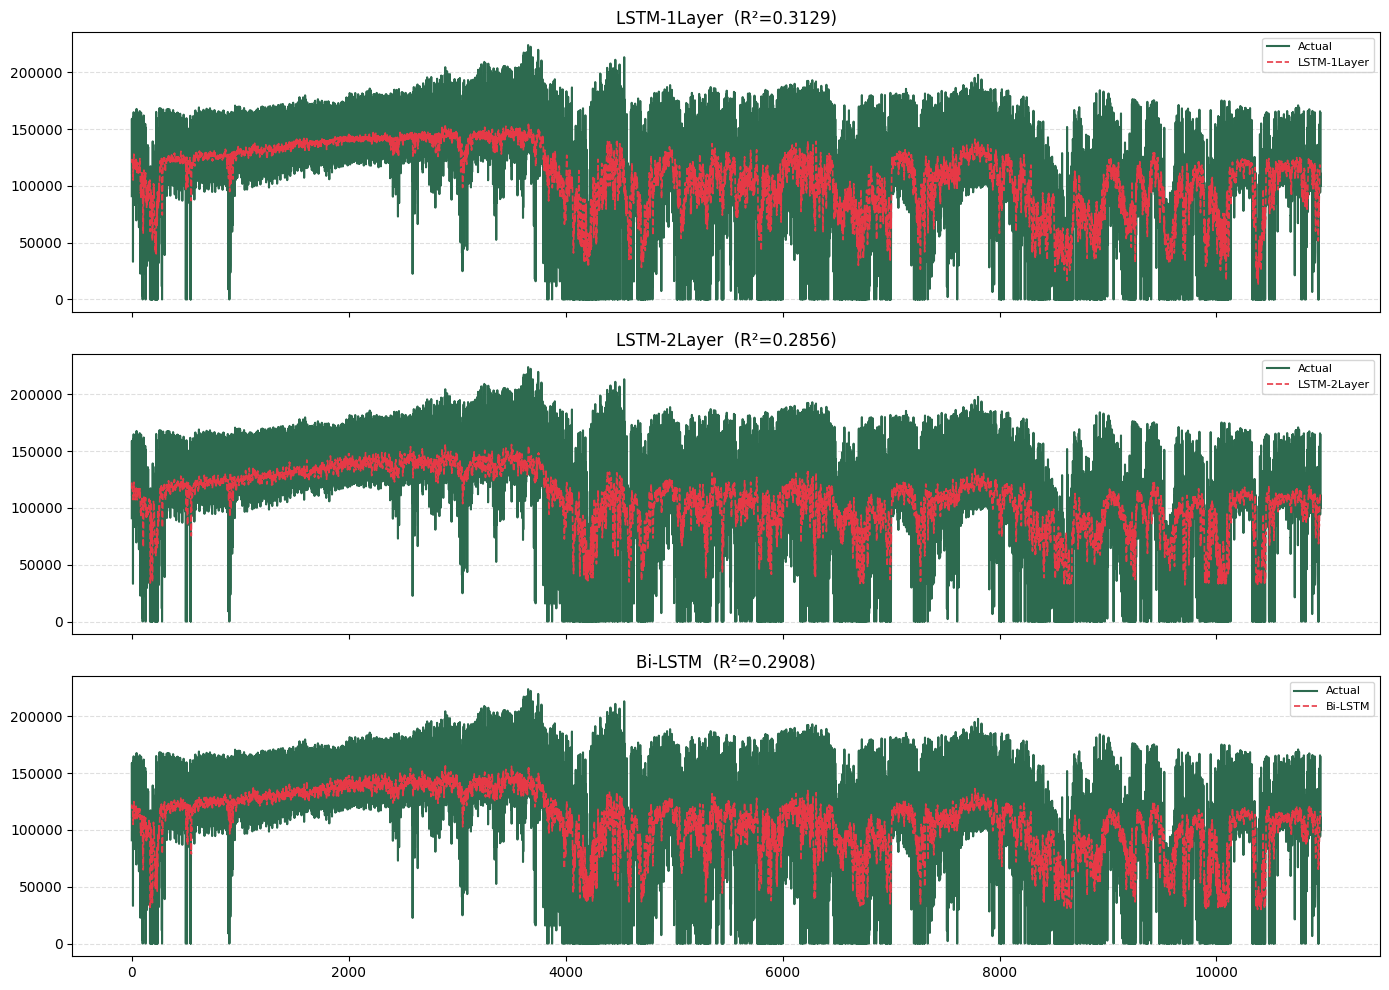

✅ Chart saved to models/lstm_predictions.png


In [7]:
y_actual = target_scaler.inverse_transform(y_te.reshape(-1,1)).flatten()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.plot(y_actual, label="Actual",    color="#2d6a4f", linewidth=1.5)
    ax.plot(y_pred,   label=f"{name}",   color="#e63946", linewidth=1.2, linestyle="--")
    ax.set_title(f"{name}  (R²={lstm_results[name]['R²']:.4f})")
    ax.legend(fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../models/lstm_predictions.png", dpi=150)
plt.show()
print("✅ Chart saved to models/lstm_predictions.png")